In [179]:
import MDAnalysis as mda
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm

In [180]:
#Copied atom selection from Reza's pull.ndx
#headgroup_original_ = 17499 17530 17562 17612 17624 18125 19043 19081 19105 19117 19584 20838
#transmembrane_original_ = 14820 14844 14860 14879 14898 14917 14927 14943 14962 14972 14979 14998 15017 15036 15055
#15065 15081 15100 15116 15136 15152 15169 26119 26135 26154 26173 26184 26200 26217 26224
#26234 26253 26272 26291 26310 26317 26336 26346 26356 26375 26394 26413

In [181]:
coor = mda.Universe('step6.0_minimization.gro')

FileNotFoundError: [Errno 2] No such file or directory: 'step6.0_minimization.gro'

In [182]:
sel_HG_ = coor.select_atoms('protein and index 17498 17529 17561 17611 17623 18124 19042 19080 19104 19116 19583 20837')

In [12]:
sel_TM_ = coor.select_atoms('protein and index 14819 14843 14859 14878 14897 14916 14926 14942 14961 14971 14978 14997 15016 15035 15054 15064 15080 15099 15115 15135 15151 15168 26118 26134 26153 26172 26183 26199 26216 26223 26233 26252 26271 26290 26309 26316 26335 26345 26355 26374 26393 26412')

# Force vs Extension

In [197]:
blues = cm.get_cmap("Reds", 12)

/var/folders/3s/vv6bsk197x73zvv9q0nr83jw0000gn/T/ipykernel_5287/3658464902.py:1: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  blues = cm.get_cmap("Reds", 10)


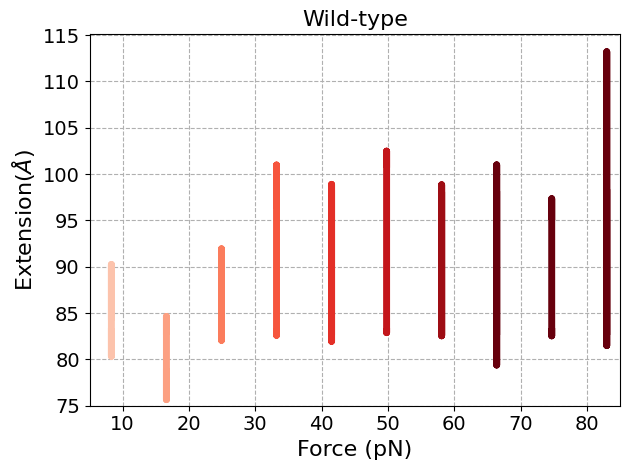

In [214]:
f_ = np.ones(1000001)
j_ = -1
array_ = np.array((5,10,15,20,25,30,35,40,45,50))
for i in range(2,12):
    x_wt = np.loadtxt('Wild-type/SMD_Force_Extension/step8_pull_pullx_fk{}.xvg'.format(array_[i-2]), comments=['#', '@'], usecols=(0,1))
    fk_ = f_*array_[i-2]*1.66
    plt.plot(fk_[:80000], x_wt[:80000,1]*10, lw=5, color=blues(i), label='{} pN'.format(int(i)*1.66))
plt.ylim(75,)
plt.xlim(5,85)

#plt.legend(fontsize=14)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlabel('Force (pN)', fontsize=16)
plt.ylabel('Extension($\AA$)', fontsize=16)
plt.grid(visible=True, linestyle='--')
plt.title('Wild-type', fontsize=16)
plt.tight_layout()
plt.savefig('Extension_vs_force_SMD_WT.png', dpi=300)

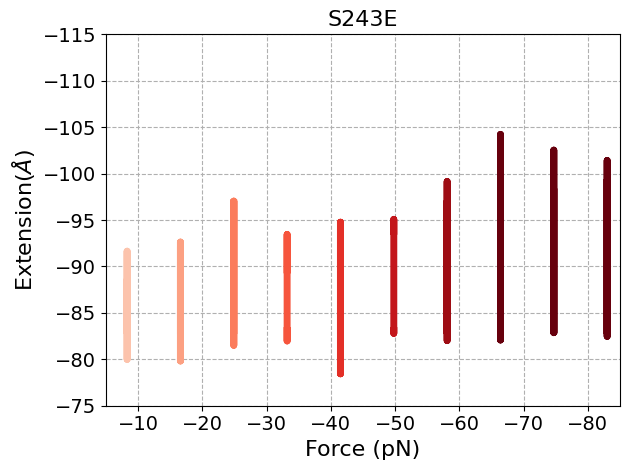

In [221]:
f_ = np.ones(1000001)
j_ = -1
array_ = np.array((5,10,15,20,25,30,35,40,45,50))
for i in range(2,12):
    x_wt = np.loadtxt('Mutant/SMD_Force_Extension/step8_pull_pullx_fk{}.xvg'.format(array_[i-2]), comments=['#', '@'], usecols=(0,1))
    fk_ = -f_*array_[i-2]*1.66
    plt.plot(fk_[:80000], x_wt[:80000,1]*10, lw=5, color=blues(i), label='{} pN'.format(int(i)*1.66))
plt.xlim(-5,-85)
plt.ylim(-75,-115)
#plt.legend(fontsize=14)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlabel('Force (pN)', fontsize=16)
plt.ylabel('Extension($\AA$)', fontsize=16)
plt.grid(visible=True, linestyle='--')
plt.title('S243E', fontsize=16)
plt.tight_layout()
plt.savefig('Extension_vs_force_SMD_mutant.png', dpi=300)

# PMF

In [21]:
for i in range(7,8):
    coor = mda.Universe('Wild-type/Centered_Traj/step6.0_minimization.tpr', 
                    'Wild-type/Centered_Traj/step8_pull_fk0_centered_rep{}.xtc'.format(i))
    sel_HG_ = coor.select_atoms('protein and index 17498 17529 17561 17611 17623 18124 19042 19080 19104 19116 19583 20837')
    sel_TM_ = coor.select_atoms('protein and index 14819 14843 14859 14878 14897 14916 14926 14942 14961 14971 14978 14997 15016 15035 15054 15064 15080 15099 15115 15135 15151 15168 26118 26134 26153 26172 26183 26199 26216 26223 26233 26252 26271 26290 26309 26316 26335 26345 26355 26374 26393 26412')
    dist = np.zeros((coor.trajectory.n_frames-1, 2))
    for ts in coor.trajectory[1:]:
        com1 = sel_HG_.center_of_mass()
        com2 = sel_TM_.center_of_mass()
        dist_ = np.linalg.norm(com1 - com2)
        dist[ts.frame-1] = ts.frame*100, dist_
    np.savetxt('Wild-type/Centered_Traj/dist_com_HG-TM_rep{}.dat'.format(i), dist)

In [22]:
for i in range(1,11):
    coor = mda.Universe('Mutant/Centered_Traj/step6.0_minimization.tpr', 
                    'Mutant/Centered_Traj/step8_pull_fk0_centered_rep{}.xtc'.format(i))
    sel_HG_ = coor.select_atoms('protein and index 17498 17529 17561 17611 17623 18124 19042 19080 19104 19116 19583 20837')
    sel_TM_ = coor.select_atoms('protein and index 14819 14843 14859 14878 14897 14916 14926 14942 14961 14971 14978 14997 15016 15035 15054 15064 15080 15099 15115 15135 15151 15168 26118 26134 26153 26172 26183 26199 26216 26223 26233 26252 26271 26290 26309 26316 26335 26345 26355 26374 26393 26412')
    dist = np.zeros((coor.trajectory.n_frames-1, 2))
    for ts in coor.trajectory[1:]:
        com1 = sel_HG_.center_of_mass()
        com2 = sel_TM_.center_of_mass()
        dist_ = np.linalg.norm(com1 - com2)
        dist[ts.frame-1] = ts.frame*100, dist_
    np.savetxt('Mutant/Centered_Traj/dist_com_HG-TM_rep{}.dat'.format(i), dist)

In [215]:
nFrames_w = 7000
nFrames_s = 10000

dist_wt = np.arange(nFrames_w, dtype=float)
frames = 0
for i in range(1,8):
    dist = np.loadtxt('Wild-type/Centered_Traj/dist_com_HG-TM_rep{}.dat'.format(i), usecols=1)
    dist_wt[frames:frames+len(dist)] = dist
    frames += len(dist)
    
dist_mt = np.arange(nFrames_s, dtype=float)
frames = 0
for i in range(1,11):
    dist = np.loadtxt('Mutant/Centered_Traj/dist_com_HG-TM_rep{}.dat'.format(i), usecols=1)
    dist_mt[frames:frames+len(dist)] = dist
    frames += len(dist)

In [216]:
dist_wt.min(), dist_wt.max(), dist_mt.min(), dist_mt.max()

(65.97440864455193, 97.89456179816708, 70.69159710878716, 100.46298892320077)

In [217]:
hist_w, bins_w = np.histogram(dist_wt, range=(65,102), density=True, bins=25)
hist_s, bins_s = np.histogram(dist_mt, range=(65,102), density=True, bins=25)

In [218]:
hist_w_E = np.zeros((3, len(bins_w)-1))
hist_w_E[0] = np.histogram(dist_wt[:3000], range=(65,102), density=True, bins=25)[0]
hist_w_E[1] = np.histogram(dist_wt[3000:6000], range=(65,102), density=True, bins=25)[0]
hist_w_E[2] = np.histogram(dist_wt[6000:], range=(65,102), density=True, bins=25)[0]
std_w = np.std(hist_w_E, axis=0)/np.sqrt(3)
std_w /= hist_w
std_w *= 0.434

/var/folders/3s/vv6bsk197x73zvv9q0nr83jw0000gn/T/ipykernel_5287/1131136070.py:6: RuntimeWarning: invalid value encountered in divide
  std_w /= hist_w


In [219]:
hist_s_E = np.zeros((3, len(bins_w)-1))
hist_s_E[0] = np.histogram(dist_mt[:2000], range=(65,102), density=True, bins=25)[0]
hist_s_E[1] = np.histogram(dist_mt[2000:4000], range=(65,102), density=True, bins=25)[0]
hist_s_E[2] = np.histogram(dist_mt[4000:], range=(65,102), density=True, bins=25)[0]
std_s = np.std(hist_s_E, axis=0)/np.sqrt(3)
std_s /= hist_s
std_s *= 0.434

/var/folders/3s/vv6bsk197x73zvv9q0nr83jw0000gn/T/ipykernel_5287/485659643.py:6: RuntimeWarning: invalid value encountered in divide
  std_s /= hist_s


/var/folders/3s/vv6bsk197x73zvv9q0nr83jw0000gn/T/ipykernel_5287/2599560675.py:3: RuntimeWarning: divide by zero encountered in log
  fe_w = -np.log(hist_w)
/var/folders/3s/vv6bsk197x73zvv9q0nr83jw0000gn/T/ipykernel_5287/2599560675.py:4: RuntimeWarning: divide by zero encountered in log
  fe_s = -np.log(hist_s)


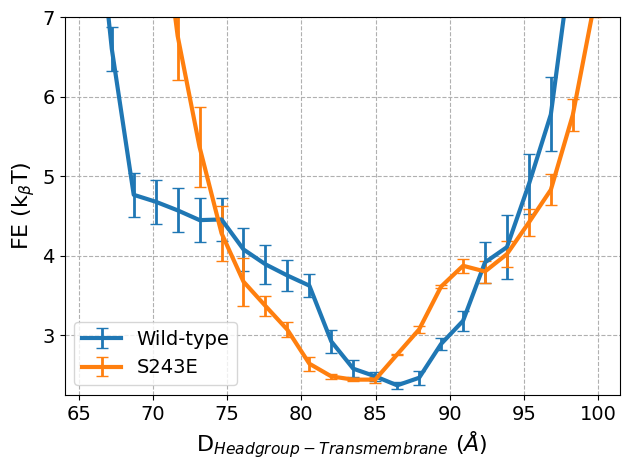

In [220]:
midpoints = bins_w[:-1]+(np.diff(bins_w)[0]/2)

fe_w = -np.log(hist_w)
fe_s = -np.log(hist_s)

#plt.plot(midpoints, fe_w-np.amin(fe_w), lw=3, label='Wild-type')

plt.errorbar(midpoints, fe_w, yerr=std_w, capsize=4, elinewidth=2, lw=3, label='Wild-type')
plt.errorbar(midpoints, fe_s, yerr=std_s, capsize=4, elinewidth=2, lw=3, label='S243E')

#plt.plot(midpoints, fe_s-np.amin(fe_s), lw=3, label='S243E')
plt.ylim(2.25,7)
plt.legend(fontsize=14)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlabel('D$_{Headgroup-Transmembrane}$ ($\AA$)', fontsize=16)
plt.ylabel(r'FE (k$_\beta$T)', fontsize=16)
plt.grid(visible=True, linestyle='--')
plt.tight_layout()
plt.savefig('FE_dist_HG-TM_wild_mutant.png', dpi=300)

In [57]:
bins_w[0]

65.0